# Constructing the diagonal TEB covariance matrix and the unitary matrix

In [23]:
import numpy as np
from numpy import sqrt
import camb
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm

In [24]:
l_max = 10

pars = camb.CAMBparams()
pars.set_cosmology(H0=67.5, ombh2=0.022, omch2=0.122, mnu=0.06, omk=0, tau=0.06)
pars.InitPower.set_params(As=2e-9, ns=0.965, r=0.1)
pars.set_for_lmax(l_max)
pars.WantTensors = True

# More accurate transfer functions. Takes longer time to run
pars.set_accuracy(AccuracyBoost = 3, lAccuracyBoost = 3, lSampleBoost = 100)
pars.Accuracy.IntkAccuracyBoost = 3
pars.Accuracy.SourcekAccuracyBoost = 3

# Get the CAMB functions and save them
data = camb.get_transfer_functions(pars)
results = camb.get_results(pars)
powers = results.get_cmb_power_spectra(pars, raw_cl=True, CMB_unit='muK')['tensor']
transfer_tensor = data.get_cmb_transfer_data(tp='tensor')

# To get C_\ell in units of umK, we multiply by 1e6 (K to micro K) and the temperature of the CMB in K
transfer_data = np.array(transfer_tensor.delta_p_l_k) * 1e6 * 2.7255
print('Shape of transfer function from CAMB:', transfer_data.shape)

# CAMB gives the transfer data for a set of k and ell. Store these values
# and later we will use interpolation for other k/ell values.
#k is in Mpc^{-1}
k_list = np.array(transfer_tensor.q)
ell_list = np.array(transfer_tensor.L)

Shape of transfer function from CAMB: (3, 599, 6454)


In [25]:
num_l_m = l_max * (l_max + 1) + l_max + 1 - 4     # = Sum[2 l+1, {l , l_min, l_max}], l_min = 2
c_lmlpmp_TEB = np.zeros((3 * num_l_m, 3 * num_l_m), dtype=np.complex128) 

In [26]:
# TT correlations
for ell in range(2, l_max + 1):
    for m in range(-ell, ell + 1):
        lm_p_index = ell * (ell+1) + m  - 4
        c_lmlpmp_TEB[lm_p_index, lm_p_index] = powers[ell, 0]
# TE correlations
for ell in range(2, l_max + 1):
    for m in range(-ell, ell + 1):
        lm_p_index = ell * (ell+1) + m  - 4
        c_lmlpmp_TEB[lm_p_index + num_l_m, lm_p_index] = powers[ell, 3]
# ET correlations
for ell in range(2, l_max + 1):
    for m in range(-ell, ell + 1):
        lm_p_index = ell * (ell+1) + m  - 4
        c_lmlpmp_TEB[lm_p_index, lm_p_index + num_l_m] = np.conjugate(powers[ell, 3])
# EE correlations
for ell in range(2, l_max + 1):
    for m in range(-ell, ell + 1):
        lm_p_index = ell * (ell+1) + m  - 4
        c_lmlpmp_TEB[lm_p_index + num_l_m, lm_p_index + num_l_m] = powers[ell, 1]
# BB correlations
for ell in range(2, l_max + 1):
    for m in range(-ell, ell + 1):
        lm_p_index = ell * (ell+1) + m  - 4
        c_lmlpmp_TEB[lm_p_index + 2 * num_l_m, lm_p_index + 2 * num_l_m] = powers[ell, 2]

In [27]:
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm
def do_cov_sub_plot(ax, normalize, ax_index, C_order, ell_range, ell_p_range):
    l_min = ell_range[0]
    l_max = ell_range[1]
    lp_min = ell_p_range[0]
    lp_max = ell_p_range[1]
    C_order = np.where(np.abs(C_order) < 1e-12, 1e-12, np.abs(C_order))

    ell_to_s_map = np.array([l * (l+1) - l - l_min**2  for l in range(l_min, l_max+1)])
    ellp_to_s_map = np.array([l * (l+1) - l - lp_min**2  for l in range(lp_min, lp_max+1)])

    axim = ax.imshow(C_order.T, cmap='inferno', norm=LogNorm(), origin='lower',  interpolation = 'nearest')


    
    if l_max-l_min > 20:
        jump = np.array([5, 10, 15, 20])-2
        ax.set_xticks(ell_to_s_map[jump]- 0.5)
        ax.set_xticklabels(np.arange(l_min, l_max+1)[jump])
    else:
        ax.set_xticks(ell_to_s_map-0.5)
        ax.set_xticklabels(np.arange(l_min, l_max+1))

    if lp_max-lp_min > 20:
        jump = np.array([5, 10, 15, 20])-2
        ax.set_yticks(ellp_to_s_map[jump]- 0.5)
        ax.set_yticklabels(np.arange(lp_min, lp_max+1)[jump])
    else:
        ax.set_yticks(ellp_to_s_map-0.5)
        ax.set_yticklabels(np.arange(lp_min, lp_max+1))
    
    
    if ax_index == 1:
        ax.set_ylabel(r"$\ell'$", fontsize = 18)
    elif ax_index == 3: 
        ax.set_xlabel(r"$\ell $", fontsize = 18) 
        ax.set_ylabel(r"$\ell'$", fontsize = 18)
    elif ax_index == 4: 
        ax.set_xlabel(r"$\ell $", fontsize = 18)
    if normalize:
        axim.set_clim(1e-7, 1e0)
    else:
        axim.set_clim(1e-14, 1e2)

    # ax.text(0.000, 0.0001, 'Additional information', horizontalalignment='center', verticalalignment='center', transform=ax1.transAxes)
    
    return axim

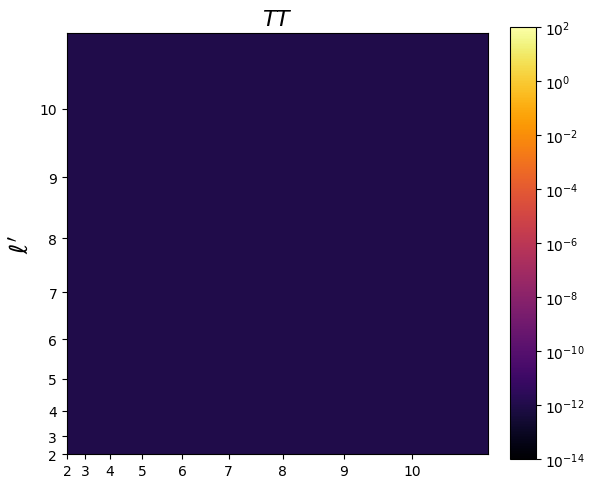

In [28]:
fig, ax = plt.subplots()
fig.tight_layout()
ell_range = np.array([2, l_max])
ell_p_range = np.array([2,l_max])
im = do_cov_sub_plot(ax, False , 1, c_lmlpmp_TEB[2*num_l_m:3*num_l_m, 0*num_l_m:1*num_l_m], ell_range, ell_p_range)
ax.set_title('$TT$', weight='bold', fontsize='16')

fig.subplots_adjust(right=0.8)
cbar_ax = fig.add_axes([0.8, 0.07, 0.04, 0.9])
fig.colorbar(im, cax=cbar_ax)

In [66]:
eigvals, eigvecs = np.linalg.eigh(c_lmlpmp_TEB)
diag_E18 = eigvecs.conj().T @ c_lmlpmp_TEB @ eigvecs
np.allclose(diag_E18, np.diag(eigvals))

True

In [67]:
from scipy.linalg import inv
c_inv_sci = inv(c_lmlpmp_TEB)
c_inv_high = eigvecs @ np.diag(1/eigvals) @ eigvecs.conj().T
np.allclose(c_inv_high, c_inv_sci, 5)

False

In [70]:
for i in range(c_inv_sci.shape[0]):
    for j in range(c_inv_sci.shape[1]):
        if np.abs((c_inv_high[i,j] - c_inv_sci[i,j])/c_inv_high[i,j])>1e-6:
            if np.abs(c_inv_high[i,j] - c_inv_sci[i,j])>1e-6:
                print(f"high = {c_inv_high[i,j]}")
                print(f"sci = {c_inv_sci[i,j]}")
                print("------------")


/tmp/ipykernel_44856/2920683140.py:3: RuntimeWarning: invalid value encountered in scalar divide
  if np.abs((c_inv_high[i,j] - c_inv_sci[i,j])/c_inv_high[i,j])>1e-6:


high = (1.7766770698424698e-06+0j)
sci = 0j
------------
high = (-4.592256215277599e-06+0j)
sci = 0j
------------
high = (-1.636818458042443e-06+0j)
sci = 0j
------------
high = (-3.814694020034753e-06+0j)
sci = 0j
------------
high = (-1.3868249386805552e-06+0j)
sci = 0j
------------
high = (1.1933568597688384e-06+0j)
sci = 0j
------------
high = (1.1273407011545447e-06+0j)
sci = 0j
------------
high = (1.1919527330252913e-06+0j)
sci = 0j
------------
high = (2.3347242304429363e-06+0j)
sci = 0j
------------
high = (-5.3858664504834115e-06+0j)
sci = 0j
------------
high = (-1.9458886845280788e-06+0j)
sci = 0j
------------
high = (-2.2236119737202058e-06+0j)
sci = 0j
------------
high = (1.0092569387749145e-06+0j)
sci = 0j
------------
high = (1.0092564887047358e-06+0j)
sci = 0j
------------
high = (2.3348345646348454e-06+0j)
sci = 0j
------------
high = (1.7587668044856015e-06+0j)
sci = 0j
------------
high = (-2.632479378013811e-06+0j)
sci = 0j
------------
high = (1.4414641896118099e

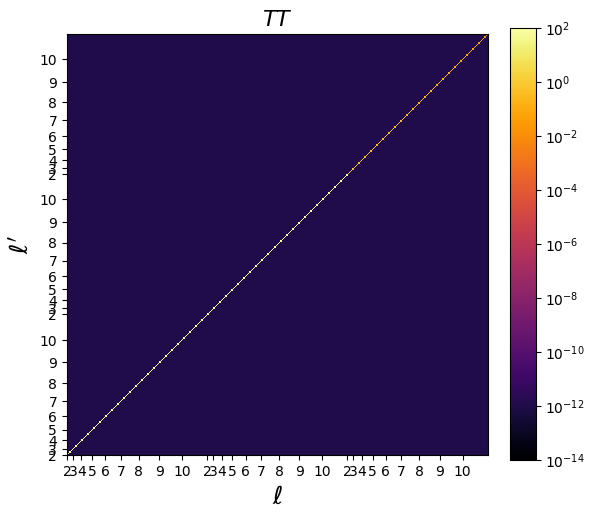

In [41]:
def do_cov_sub_plot(ax, C_order, ell_range, ell_p_range):
    l_min = ell_range[0]
    l_max = ell_range[1]
    lp_min = ell_p_range[0]
    lp_max = ell_p_range[1]
    C_order = np.where(np.abs(C_order) < 1e-12, 1e-12, np.abs(C_order))

    ofset = int((l_max+1) * (l_max+2) - (l_max+1) - l_min**2) 
    ell_to_s_map = np.array([l * (l+1) - l - l_min**2  for l in range(l_min, l_max+1)])
    x_tick = np.concatenate((ell_to_s_map, ell_to_s_map + ofset, ell_to_s_map + 2 * ofset))
    ellp_to_s_map = np.array([l * (l+1) - l - lp_min**2  for l in range(lp_min, lp_max+1)])
    y_tick = np.concatenate((ellp_to_s_map, ellp_to_s_map + ofset, ellp_to_s_map + 2 * ofset))

    axim = ax.imshow(C_order, cmap='inferno', norm=LogNorm(), origin='lower',  interpolation = 'nearest')


    
    if l_max-l_min < 10:
        ax.set_xticks(x_tick-.5)
        ax.set_xticklabels(np.concatenate((np.arange(lp_min, lp_max+1), np.arange(lp_min, lp_max+1), np.arange(lp_min, lp_max+1))))

    if lp_max-lp_min < 10:
        ax.set_yticks(y_tick-.5)
        ax.set_yticklabels(np.concatenate((np.arange(lp_min, lp_max+1), np.arange(lp_min, lp_max+1), np.arange(lp_min, lp_max+1))))
    
    
    ax.set_xlabel(r"$\ell $", fontsize = 18) 
    ax.set_ylabel(r"$\ell'$", fontsize = 18)

    axim.set_clim(1e-14, 1e2)

    return axim

fig, ax = plt.subplots()
fig.tight_layout()
ell_range = np.array([2, l_max])
ell_p_range = np.array([2,l_max])
im = do_cov_sub_plot(ax, np.diag(1/eigvals), ell_range, ell_p_range)
ax.set_title('$TT$', weight='bold', fontsize='16')

fig.subplots_adjust(right=0.8)
cbar_ax = fig.add_axes([0.8, 0.07, 0.04, 0.9])
fig.colorbar(im, cax=cbar_ax)

In [ ]:
np.save('unitary_matrix_lmax_{}.npy'.format(l_max), eigvecs)
np.save('diagonal_TEB_E18_lmax_{}.npy'.format(l_max), diag_E18)